# WFS Live: Acquisition and Reconstruction at ALS BL 5.3.1

__Authors:__ 
- Wei "Francis" He (francisho@lbl.gov, whorwhey@gmail.com)  
- Ka Hung (Henry) Chan (khchan@lbl.gov)
- Antoine İşlegen-Wojdyla (awojdyla@lbl.gov)
- Walan Grizolli (walangrizolli@lbl.gov)

Notebook created date: 2026-06-09

Experiment date: 

## Overview

Operate the grating-based shearing-interferometry wavefront sensor at BL 5.3.1: configure motors and detector, run Bluesky scans (point counts, line scans, energy/bender grids), pull data via Tiled, and reconstruct wavefronts live with `wfs_live.py`.

We added capture of the beam at the sample. It doesn't quite work but we're close. We want to acquire a clean grid scan over bender and energy without any binning.

We want to add relevant metadata (exposure time, pixel size/camera model, binning) so that we can scale data accordingly (effective flux, effective size).

# SETUP 

## Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.simplefilter('always', RuntimeWarning)

In [2]:
import monoplus as mp
import wfs_live as wfl

# from bluesky import plans as bp
from tiled.client import from_uri


## Beamline connection: motors, detector, Bluesky/Tiled
 
Pre-flight checks before running this section:
- **Basler camera:** confirm the EPICS IOC is running (PV prefix `BL531acA5427:` for `basler_5472`, `BL531a2A2448:` for `basler_2448`).
- **BCS stages:** confirm in LabVIEW that the BCS motors (`Galil x.20 A` linear, `Galil x.20 B` rotary) are connected and operational.


In [ ]:
# Bender motor (M1) via EPICS. Software low-limit backs up the hardware limit.

from ophyd import EpicsMotor
Obender = EpicsMotor('bl531_esp300:m101_bend_um', name='bender_um')
Obender.low_limit_travel.set(-2000)

In [ ]:
# Monochromator energy axis. nabla.nophyd provides the BL 5.3.1 ophyd
# wrappers (MonoEnergy, BaslerDetector, BCSMotor). MonoEnergy('') is
# constructed with empty prefix because the underlying motor uses a full PV path internally.

import sys
sys.path.append('/home/bl531/python/nabla/')
from nabla.nophyd import MonoEnergy, BaslerDetector, BCSMotor

mono_energy = MonoEnergy('', name='mono_energy')

In [ ]:
# Basler cameras: basler_5472 = primary WFS detector, basler_2448 = sample-
# plane view (not fully wired). Each connection lives in its own try block
# so a failure on one camera doesn't abort the other. Stage signals are
# applied at each acquisition and restored after; TIFFs are auto-saved
# per frame so Tiled can index them.

BASLER_FILES_ROOT = "/mnt/data531"
BASLER_5472_IMAGE_DIR = "scans/%Y/%m/%d/basler5472"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs
BASLER_2448_IMAGE_DIR = "scans/%Y/%m/%d/basler2448"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs

# --- basler_5472 (primary WFS detector) ---
try:
    basler_5472 = BaslerDetector(
        "BL531acA5427:",
        name="basler_5472",
        image_dir=BASLER_5472_IMAGE_DIR,
    )

    # Stage signals — set before each acquisition, restored after
    basler_5472.cam.stage_sigs['image_mode']    = 'Single'
    basler_5472.cam.stage_sigs['num_images']    = 1
    basler_5472.cam.stage_sigs['acquire_time']  = 2
    basler_5472.cam.stage_sigs['acquire_period'] = 0.5

    # TIFF plugin: filename template + auto-save per frame
    basler_5472.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    basler_5472.tiff.stage_sigs['enable']        = 1
    basler_5472.tiff.stage_sigs['auto_save']     = 'Yes'
    basler_5472.tiff.stage_sigs['file_write_mode'] = 'Single'

    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    basler_5472.read_attrs      = ['tiff']
    basler_5472.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531acA5427:'")

# --- basler_2448 (sample-plane view — not fully wired) ---
try:
    basler_2448 = BaslerDetector(
        "BL531a2A2448:",
        name="basler_2448",
        image_dir=BASLER_2448_IMAGE_DIR,
    )

    # Stage signals — set before each acquisition, restored after
    basler_2448.cam.stage_sigs['image_mode']    = 'Single'
    basler_2448.cam.stage_sigs['num_images']    = 1
    basler_2448.cam.stage_sigs['acquire_time']  = 1
    basler_2448.cam.stage_sigs['acquire_period'] = 1.1
    # basler_2448.cam.stage_sigs['trigger_mode'] = 'Off' 
    basler_2448.cam.stage_sigs['array_callbacks'] = 1

    # TIFF plugin config disabled for now — re-enable once 2448 acquisition is finalized
    # basler_2448.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # basler_2448.tiff.stage_sigs['enable']        = 1
    # basler_2448.tiff.stage_sigs['auto_save']     = 'Yes'
    # basler_2448.tiff.stage_sigs['file_write_mode'] = 'Single'

    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    # basler_2448.read_attrs      = ['tiff']
    # basler_2448.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531a2A2448:'")

In [ ]:
# BCS Galil motors live behind a LabVIEW server reachable over TCP.
# Open the connection, sanity-check linear position via raw TCP, then
# wrap each motor as an ophyd-compatible BCSMotor for use in Bluesky plans.

import bcs_tcp

# --- TCP connection to the BCS LabVIEW server ---
ALSU_BOSS_IP = "131.243.80.251"
(host_ip_addr, host_port, host_timeout) = (ALSU_BOSS_IP, 55000, 5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

# Motor id strings (must match LabVIEW configuration)
bcs_id_linear = 'Galil x.20 A'
bcs_id_rotary = 'Galil x.20 B'

# Sanity check — read linear motor position via raw TCP
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print(f'linear stage position is {pos_lin_mm} mm')

# --- Wrap motors as ophyd-compatible BCSMotor objects ---
bcs_linear_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_linear,
    settle_time=0.5,
    tolerance=0.001,
    name='bcs_linear_motor',
)

bcs_rotary_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_rotary,
    settle_time=0.5,
    tolerance=0.01,
    name='bcs_rotary_motor',
)

# --- Confirm both motors respond ---
print(f'Linear motor position : {bcs_linear_motor.position} mm')
print(f'Rotary motor position : {bcs_rotary_motor.position} deg')
print(bcs_linear_motor)
print(bcs_rotary_motor)

In [ ]:
# RunEngine + Tiled plumbing. Run/rerun this cell to rebuild RE,
# tiled_client, and sd.baseline (e.g. after a kernel restart).
#   1. Instantiate the Bluesky RunEngine.
#   2. Connect to the local Tiled server and subscribe a TiledWriter to ingest scan documents.
#   3. Build a central-Tiled writer with a path-patch (currently NOT subscribed — central
#      server doesn't accept local resource paths yet).
#   4. Attach BestEffortCallback for live stdout updates.
#   5. Attach a SupplementalData preprocessor so every scan records a baseline
#      stream with start/stop positions of the key motors.

# The queue server must include the "keep_re" parameter which prevents the RE in this startup script from being overwritten

import os
from bluesky import RunEngine
from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.callbacks.tiled_writer import TiledWriter
from bluesky.preprocessors import SupplementalData

# --- RunEngine ---
RE = RunEngine({})

# --- Local Tiled client + writer ---
# Load the API key from env var
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)
tw = TiledWriter(tiled_client, batch_size=1)

# --- Central Tiled client + writer (not subscribed yet) ---
# Doesn't work yet: the central server isn't configured to accept resource
# documents with local file paths. We patch each resource document to swap
# LOCAL_PATH_PREFIX for CENTRAL_PATH_PREFIX before sending.
central_tiled_api_key = os.getenv("CENTRAL_API_KEY")
if not central_tiled_api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

central_tiled_client = from_uri("https://tiled.computing.als.lbl.gov/api/v1/metadata/beamlines/bl531/raw", api_key=central_tiled_api_key)

LOCAL_PATH_PREFIX = "mnt/data531"
CENTRAL_PATH_PREFIX = "/global/beegfs/beamlines/bl531/raw"

def patch_ride_filenames(doc: dict):
    """
    a TiledWriter will be sending documents to the central Tiled server.
    For resource documents, we want to patch resource_path;
    Add CENTRAL_PATH_PREFIX in place of LOCAL_PATH_PREFIX as the root key
    Strip LOCAL_PATH_PREFIX from the beginning of resource_path, if it exists
    :param doc_name: Description
    :type doc_name: str
    :param doc: Description
    :type doc: dict
    """    
    resource_path = doc.get("resource_path", "")
    if resource_path.startswith(LOCAL_PATH_PREFIX):
        # Strip LOCAL_PATH_PREFIX and prepend CENTRAL_PATH_PREFIX
        relative_path = resource_path[len(LOCAL_PATH_PREFIX):].lstrip("/")
        new_resource_path = os.path.join(CENTRAL_PATH_PREFIX, relative_path)
        doc["resource_path"] = new_resource_path
        # print(f"Patched resource_path: {resource_path} -> {new_resource_path}")
    return doc

central_tiled_writer = TiledWriter(central_tiled_client, batch_size=1, patches={"resource": patch_ride_filenames})
# uncomment this to connect to central tiled server
# RE.subscribe(central_tiled_writer)

# --- Subscribe writers + best-effort callback ---
RE.subscribe(tw)

bec = BestEffortCallback()
bec.disable_plots()
RE.subscribe(bec)

# --- Baseline stream: snapshot motor positions at scan start/stop ---
sd = SupplementalData()
RE.preprocessors.append(sd)
sd.baseline = []
if sd:
#    sd.baseline = [mono_energy, Obender, bcs_linear_motor, basler_5472.cam.stage_sigs['acquire_time']] #for now just adding these two. add more as needed.
    sd.baseline = [mono_energy, Obender, bcs_linear_motor] # for now just adding these two. add more as needed.

## Check data acquisition

Single-frame sanity scan to verify the EPICS → Bluesky → Tiled chain and to lock in the metadata template (`md`) reused by every scan below.


In [ ]:
# Build the md dict that every downstream scan will reuse, then run a single
# bp.count to verify the full RE → TIFF → Tiled chain end to end.
# cam model + acquire_time are auto-captured by Tiled from cam config; no need in md.

objective_model = "Mitutoyo Plan Apo HR 5X"
pixel_size_um   = 2.4    # Basler chip native pixel size
objective_mag   = 5

binx = basler_5472.cam.bin_x.read()['basler_5472_cam_bin_x']['value']
biny = basler_5472.cam.bin_y.read()['basler_5472_cam_bin_y']['value']
effective_pixel_size_um = pixel_size_um * binx / objective_mag

md = {
    'pixel size [um]':            f"{pixel_size_um}",
    'binning':                    f"{binx}x{biny}",
    'effective pixel size [um]':  f"{effective_pixel_size_um}",
    'objective model':            f"{objective_model}",
}

uid = RE(bp.count([basler_5472], num=1, md=md))

In [ ]:
# Read back the configuration (hardware-reported) and start metadata (user md)
# to confirm the round trip into Tiled worked.

db = tiled_client[uid]

# Hardware-reported via cam configuration
cam_cfg      = db['primary'].metadata['configuration']['basler_5472']['data']
exp_time_s   = cam_cfg['basler_5472_cam_acquire_time']
camera_model = cam_cfg['basler_5472_cam_model']

# User md
start = db.metadata['start']
pixel_size_um           = start.get('pixel size [um]')
binning                 = start.get('binning')
effective_pixel_size_um = start.get('effective pixel size [um]')
objective_model         = start.get('objective model')

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning})")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")

In [ ]:
# Read baseline (motor positions at scan start/stop) and primary (image data).

wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
energy_eV       = db['baseline']['mono_energy_energy_eV'].read()
bender_um       = db['baseline']['bender_um'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
print(f"Mono energy (eV):       {energy_eV}")
print(f"Bender position (µm):   {bender_um}")

images = db['primary']['basler_5472_image'].read()
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")

In [ ]:
# Eyeball the captured frame.

idx = 0
plt.figure(figsize=(12, 4))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx={idx}   E={energy_eV[0]:.0f} eV   '
          f'bender={bender_um[0]:.0f} µm   chip_pos={wfs_chip_pos_mm[0]:.3f} mm')
plt.xlabel('y [pixels]'); plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout(); plt.show()

# DATA COLLECTION

## Templates
 
Recipes for the four things you'll do over and over during beamtime: check/move motors, run a scan, pull data back from Tiled, and reconstruct a wavefront from one frame.


### Check / move motors

In [ ]:
# Current motor positions 
# Each axis is read via .get(); the underlying ophyd wrappers expose both the commanded setpoint
# and the live readback so the two can be compared at a glance (large mismatch = motor hasn't settled).
print(f"Energy:           setpoint {mono_energy.get().energy_eV.setpoint:.1f} eV  (readback {mono_energy.get().energy_eV.readback:.1f} eV)")
print(f"Bender:           setpoint {Obender.get().user_setpoint:.0f} µm  (readback {Obender.get().user_readback:.0f} µm)")
print(f"bcs_linear_motor: {bcs_linear_motor.get():.3f} mm")


In [ ]:
# Move motors to a known starting state (Chip 1 default)
mono_energy.move(8000)
Obender.move(-2000)
bcs_linear_motor.move(4.410)

### Run a scan
 
Three patterns. Each assigns the returned uid to `uid_template` so the data-access template below can reuse it.

All three pass `md=md`, the metadata dict built in the Check data acquisition section.

In [ ]:
# Setup metadata for scans

objective_model = "Mitutoyo Plan Apo HR 5X"
pixel_size_um   = 2.4    # Basler chip native pixel size
objective_mag   = 5

binx = basler_5472.cam.bin_x.read()['basler_5472_cam_bin_x']['value']
biny = basler_5472.cam.bin_y.read()['basler_5472_cam_bin_y']['value']
effective_pixel_size_um = pixel_size_um * binx / objective_mag

md = {
    'pixel size [um]':            f"{pixel_size_um}",
    'binning':                    f"{binx}x{biny}",
    'effective pixel size [um]':  f"{effective_pixel_size_um}",
    'objective model':            f"{objective_model}",
}

In [ ]:
# Single frame snapshot
uid_template = RE(bp.count([basler_5472], num=1, md=md))

In [ ]:
# 1-D scan over one motor (example: mono_energy 7500→9500, 11 points)
# Swap motor / start / stop / npts to scan any other axis (mono_energy, Obender, ...).
uid_template = RE(bp.scan([basler_5472], mono_energy, 7500, 9500, 11, md=md))

In [ ]:
# 2-D grid scan: snake_axes=False keeps the inner direction the same on every outer step,
# so frame i maps to (e_idx, b_idx) = (i // n_inner, i % n_inner).
uid_template = RE(bp.grid_scan(
    [basler_5472],
    mono_energy, 7000, 9000, 11,    # ourter axis
    Obender, -2000, -1400, 13,      # inner axis
    snake_axes=False, md=md,
))

### Load data and parameters
 
Data: `RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -2000, -1400, 13, snake_axes=False, md=md))`
- uid = `'4adb81df-534d-4fc9-8590-ab1a449e5b54'`
- d = 7 µm

In [5]:
# Load scan data from Tiled
# 'primary' stream holds per-frame data (images + scanned motor positions);
# 'baseline' stream (used elsewhere) holds start/stop positions of unscanned motors.

db = tiled_client['4adb81df-534d-4fc9-8590-ab1a449e5b54']
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()

print(f"images: {images.shape}")
print(f"E range:      {energy_eV.min():.0f} – {energy_eV.max():.0f} eV")
print(f"bender range: {bender_um.min():.0f} – {bender_um.max():.0f} µm")

images: (143, 2900, 1100)
E range:      7000 – 9000 eV
bender range: -2000 – -1400 µm


In [6]:
# Physical parameters
effective_pixel_size_um = float(db.metadata['start']['effective pixel size [um]']) 
dx_m            = effective_pixel_size_um * 1e-6    # effective pixel size on the detector read from md, varies with binning + objective
grating_pitch_m = 7e-6          # candidates: 4.4, 4.9, 5.5, 6.2, 7 µm
z_gd_m          = 0.3           # grating-to-detector distance

wavelength_m_arr = wfl.energy_eV_to_wavelength_m(energy_eV)

print(f"dx (effective): {dx_m*1e6:.3f} µm")
print(f"grating pitch:  {grating_pitch_m*1e6:.1f} µm")
print(f"z_gd:           {z_gd_m*1e3:.0f} mm")
print(f"λ range:        {wavelength_m_arr.min()*1e9:.4f} – {wavelength_m_arr.max()*1e9:.4f} nm")

dx (effective): 0.480 µm
grating pitch:  7.0 µm
z_gd:           300 mm
λ range:        0.1378 – 0.1771 nm


### Reconstruct wavefronts

__Single frame__

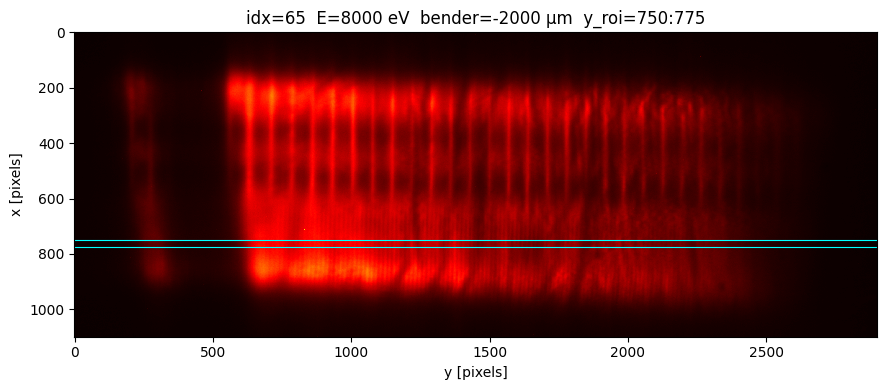

In [7]:
# Pick a frame and eyeball the ROI band
idx   = 65
y_roi = slice(750, 775)

img = images[idx]
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(img.T, cmap='hot', interpolation='nearest', vmax=4000)
ax.axhline(y_roi.start, color='cyan', lw=0.8)
ax.axhline(y_roi.stop,  color='cyan', lw=0.8)
ax.set_title(f'idx={idx}  E={energy_eV[idx]:.0f} eV  bender={bender_um[idx]:.0f} µm  '
             f'y_roi={y_roi.start}:{y_roi.stop}')
ax.set_xlabel('y [pixels]'); ax.set_ylabel('x [pixels]')
plt.tight_layout(); plt.show()

[  ok]  λ=0.15nm  k_peak=135.1 cyc/mm  r_DC=150.9  SNR=39.7  f_pred=-4.66m  RMS_W=9.4nm  RMS_resid=0.582nm  z_focus=-5.10m(fwhm_min)  RMS@focus=0.135nm


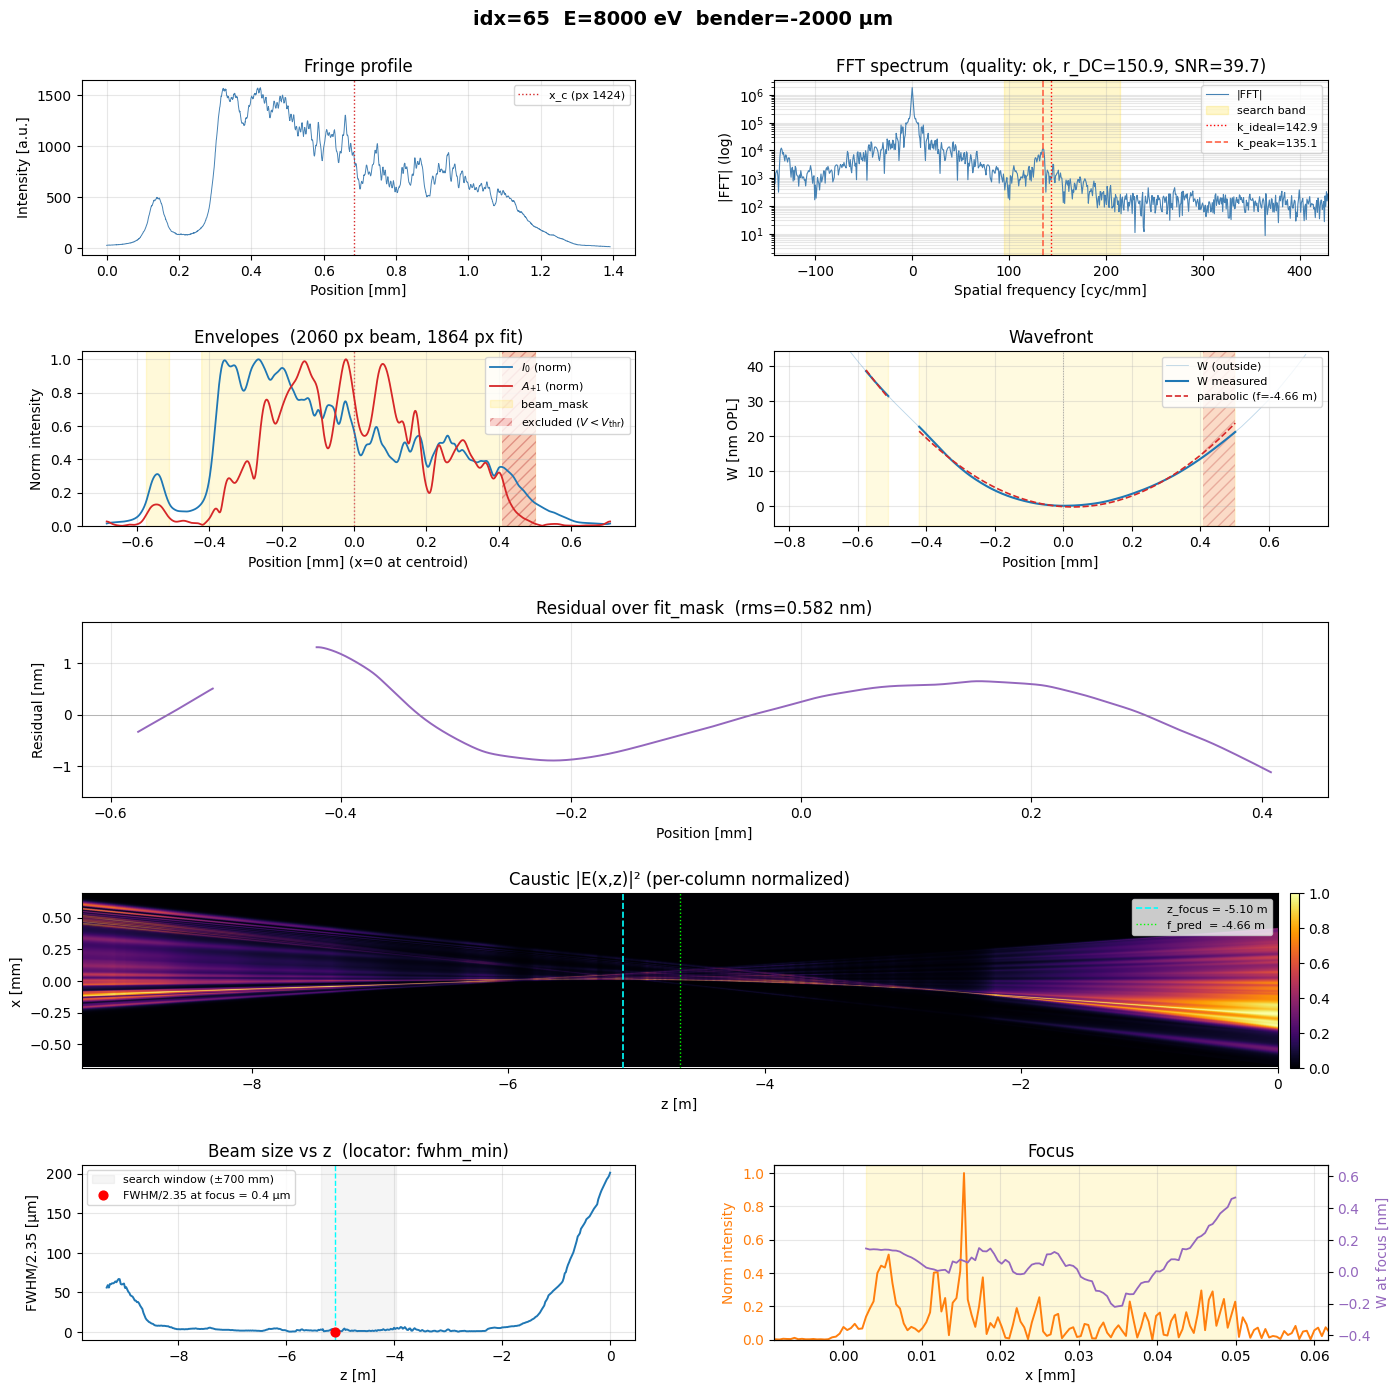

In [8]:
# Single-frame reconstruction 
# quick_look = reconstruct_single + plot_result.
# propagate=True triggers the caustic + focus computation (heavier, but needed
# for z_focus / sigma_focus). 
# caustic_amplitude='gated' and fill_gaps=False are the Stage-B/C-validated defaults;
# leave them alone unless debugging.

result = wfl.quick_look(
    images[idx], dx_m, grating_pitch_m, wavelength_m_arr[idx], z_gd_m,
    y_roi=y_roi, axis=1,
    propagate=True,
    caustic_amplitude='gated',
    fill_gaps=False,
    title=f'idx={idx}  E={energy_eV[idx]:.0f} eV  bender={bender_um[idx]:.0f} µm',
)

__Multi-frame comparison__

Two sweep types:
- **Sweep 1** — fixed E=8000 eV, vary bender: frame indices 65–77 (13 frames).
- **Sweep 2** — fixed bender=−1900 µm, vary energy: frame indices 2, 15, 28, 41, 54, 67, 80, 93, 106, 119, 132 (11 frames).

Each sweep has a loop cell (silently runs `reconstruct_single` per frame, collects result dicts) and a plot cell (2×2 panel: W(x) overlay, residual overlay, f_pred vs param, z_focus vs param). Flagged frames (`quality != 'ok'`) are kept in the plots with dashed + transparent style and a single "flagged" legend entry.

In [9]:
# Sweep 1 — fixed E=8000 eV, vary bender. Loop reconstruct_single over the
# 13 frames at e_idx=5; collect result dicts + the swept-parameter array.
indices_s1     = list(range(65, 78))                # 5*13 + 0..12
bender_s1      = bender_um[indices_s1]
results_s1     = []
for i in indices_s1:
    r = wfl.reconstruct_single(
        images[i], dx_m, grating_pitch_m, wavelength_m_arr[i], z_gd_m,
        y_roi=y_roi, axis=1,
        propagate=True,
        caustic_amplitude='gated',
        fill_gaps=False,
    )
    results_s1.append(r)

print(f"Reconstructed {len(results_s1)} frames "
      f"({sum(r['quality']=='ok' for r in results_s1)} ok, "
      f"{sum(r['quality']!='ok' for r in results_s1)} flagged).")

Reconstructed 13 frames (11 ok, 2 flagged).


/Users/francisho/Library/CloudStorage/OneDrive-UCSanDiego/Research/Projects/nabla/wfs-als531/wfs_live.py:1111: RuntimeWarning: propagate_to_focus: fwhm_min minimum landed on the search window boundary (z=-4.007 m, window ±0.523 m around f_pred=-3.486 m).
  prop = propagate_to_focus(


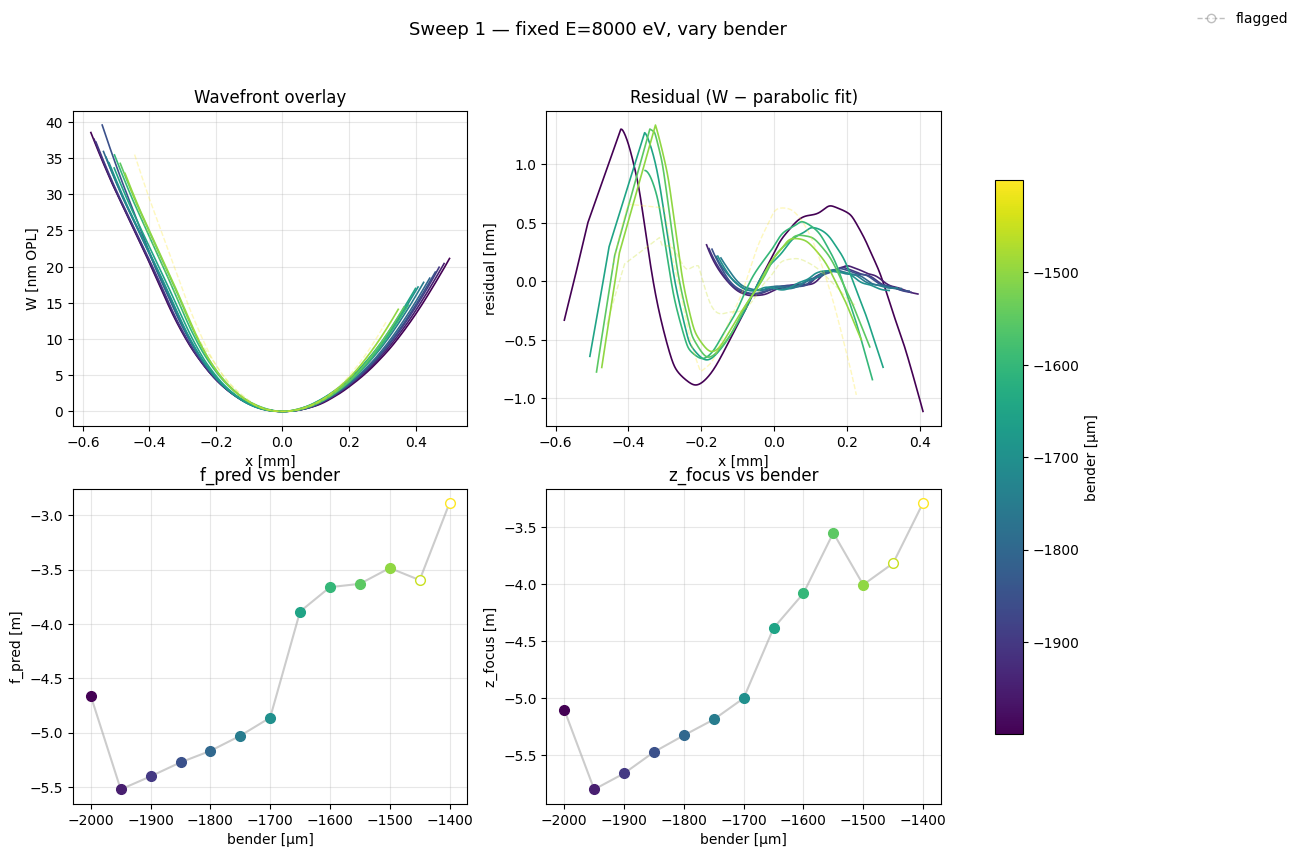

In [10]:
# Sweep 1 — 2×2 plot panel. Color-coded by bender; flagged frames get
# alpha=0.3 + dashed style and an open marker on the scalar panels.
from matplotlib.cm import viridis
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

param   = np.asarray(bender_s1)
norm    = Normalize(vmin=param.min(), vmax=param.max())
colors  = viridis(norm(param))
has_flag = any(r['quality'] != 'ok' for r in results_s1)

fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# (a) W(x) overlay
for r, p, c in zip(results_s1, param, colors):
    m  = r['beam_mask']
    ok = r['quality'] == 'ok'
    ax[0, 0].plot(r['x_mm'][m], r['W_nm'][m],
                  color=c, lw=1.2 if ok else 1.0,
                  alpha=1.0 if ok else 0.3, ls='-' if ok else '--')
ax[0, 0].set_xlabel('x [mm]'); ax[0, 0].set_ylabel('W [nm OPL]')
ax[0, 0].set_title('Wavefront overlay'); ax[0, 0].grid(alpha=0.3)

# (b) Residual overlay (inside fit_mask, converted from rad → nm with each frame's λ)
for r, p, c in zip(results_s1, param, colors):
    fm = r['fit_mask']
    resid_nm = r['W_resid_rad'] * r['wavelength'] / (2*np.pi) * 1e9
    ok = r['quality'] == 'ok'
    ax[0, 1].plot(r['x_mm'][fm], resid_nm[fm],
                  color=c, lw=1.2 if ok else 1.0,
                  alpha=1.0 if ok else 0.3, ls='-' if ok else '--')
ax[0, 1].set_xlabel('x [mm]'); ax[0, 1].set_ylabel('residual [nm]')
ax[0, 1].set_title('Residual (W − parabolic fit)'); ax[0, 1].grid(alpha=0.3)

# (c) f_pred vs bender
for r, p, c in zip(results_s1, param, colors):
    ok = r['quality'] == 'ok'
    ax[1, 0].plot(p, r['f_pred'], 'o', color=c,
                  mfc=c if ok else 'white', mec=c, ms=7)
ax[1, 0].plot(param, [r['f_pred'] for r in results_s1], '-', color='gray', alpha=0.4, zorder=0)
ax[1, 0].set_xlabel('bender [µm]'); ax[1, 0].set_ylabel('f_pred [m]')
ax[1, 0].set_title('f_pred vs bender'); ax[1, 0].grid(alpha=0.3)

# (d) z_focus vs bender
for r, p, c in zip(results_s1, param, colors):
    ok = r['quality'] == 'ok'
    ax[1, 1].plot(p, r['z_focus'], 'o', color=c,
                  mfc=c if ok else 'white', mec=c, ms=7)
ax[1, 1].plot(param, [r['z_focus'] for r in results_s1], '-', color='gray', alpha=0.4, zorder=0)
ax[1, 1].set_xlabel('bender [µm]'); ax[1, 1].set_ylabel('z_focus [m]')
ax[1, 1].set_title('z_focus vs bender'); ax[1, 1].grid(alpha=0.3)

# Colorbar (shared) + flagged-legend (one entry, only if needed)
sm = plt.cm.ScalarMappable(cmap=viridis, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), label='bender [µm]', shrink=0.8)
if has_flag:
    flag_handle = Line2D([0], [0], color='gray', lw=1.0, ls='--', alpha=0.5,
                         marker='o', mfc='white', mec='gray', label='flagged')
    fig.legend(handles=[flag_handle], loc='upper right', frameon=False)

fig.suptitle('Sweep 1 — fixed E=8000 eV, vary bender', fontsize=13)
plt.show()

## Measurements
